<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h1 style="background:linear-gradient(135deg,#22313d 0%,#284740 100%);color:#edf5f3;padding:18px 22px;border-radius:20px;border:1px solid #3a5255;border-left:10px solid #78b0a1;box-shadow:0 10px 24px rgba(0,0,0,0.20);margin:0 0 18px 0;">RLHF and LLM Alignment - Interview Preparation Guide</h1>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">Table of Contents</h2>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#what-is-policy-in-rl">RL Foundations: Policy, Value Function, Actor-Critic</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#overview-of-rlhf">Overview of RLHF Pipeline</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#rlhf-pipeline-visual">RLHF Pipeline ASCII Diagram</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#lamma-chat-2-rlhf">Llama-2-chat RLHF Case Study</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#understanding-target-modules-in-llama-models">Understanding Target Modules in LLaMA Models</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#fine-tuning-with-preference-alignment">Preference Alignment and Preference Data</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#direct-preference-optimization-dpo">Direct Preference Optimization (DPO)</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#odds-ratio-preference-optimization-orpo">Odds Ratio Preference Optimization (ORPO)</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#kto---kahneman-tversky-optimization">KTO - Kahneman-Tversky Optimization</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#constitutional-ai-anthropics-approach">Constitutional AI (Anthropic's Approach)</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#grpo---group-relative-policy-optimization">GRPO - Group Relative Policy Optimization</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#reward-hacking-and-overoptimization">Reward Hacking and Overoptimization</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#master-comparison-table-all-alignment-methods">Master Comparison Table: All Alignment Methods</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#decision-guide-when-to-use-which-alignment-method">When to Use Which Alignment Method - Decision Guide</a></li>
<li style="margin:6px 0;"><a style="color:#8fd1ff;" href="#top-12-alignment-interview-qa-with-30-second-answers">Top 12 Alignment Interview Q&amp;A</a></li>
</ol>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">What is Policy in RL?</h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">In Reinforcement Learning (RL), a  <strong>policy</strong>  is a strategy that an agent uses to decide which action to take in a given state.</p>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Deterministic Policy (π(s))</strong>  → Always selects the same action for a given state.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Stochastic Policy (π(a|s))</strong>  → Defines a probability distribution over actions for a given state.</p>
</blockquote>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">*<em>_The goal in RL is to <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">learn an optimal policy</code> (π</em>) <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">that maximizes cumulative reward._**</code></p>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">What is the Value function?</h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">The  <strong>value function</strong>  tells us how good a state or action is in terms of future rewards.</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>State value (V)</strong>  → How good it is to be in a state.</li>
<li style="margin:6px 0;"><strong>Action value (Q)</strong>  → How good it is to take a specific action in a state.</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong><em>How it connects to policy:</em></strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">A  <strong>policy</strong>  decides what actions to take.</li>
</ul>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;"></blockquote>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The  <strong>value function</strong>  helps improve the policy by estimating which states/actions lead to higher rewards.</li>
</ul>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">The better the value estimates, the better the policy can become!</p>
</blockquote>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">What is the Critic-Actor model in RL?</h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Quite similar to GANs where we’ve Generator and Discriminator models fighting throughout the training, a similar concept exists in RL Actor-Critic-Models where :</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Actor-Critic (A2C, A3C)</strong>  is a popular RL architecture that combines two components:</p>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Actor</strong>  — Learns the  <strong>policy</strong>  (πθ) and decides actions.</li>
<li style="margin:6px 0;"><strong>Critic</strong>  — Evaluates the  <strong>value function</strong>  (V(s)) to guide the actor.</li>
</ol>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">How it works:</h2>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The  <strong>actor</strong>  updates the policy based on the critic’s feedback.</li>
<li style="margin:6px 0;">The  <strong>critic</strong>  estimates the expected reward and reduces variance in learning.</li>
</ul>



### Overview of RLHF

- `RLHF is a technique that enhances pre-trained language or behavior models by aligning them with human values and preferences`. 
- Instead of solely learning from raw data, the model also incorporates human evaluations—typically in the form of `rankings` or `ratings—which serve as rewards` in a reinforcement learning (RL) setup. 
- This process improves the model’s performance by teaching it what humans consider “good” behavior.

**Key idea:**  
- **Pretrained Model → Supervised Fine-Tuning → Reward Model Creation → Reinforcement Learning (e.g., PPO)**

---

### Stage 1: RLHF Step 1: Supervised finetuning of the pretrained model
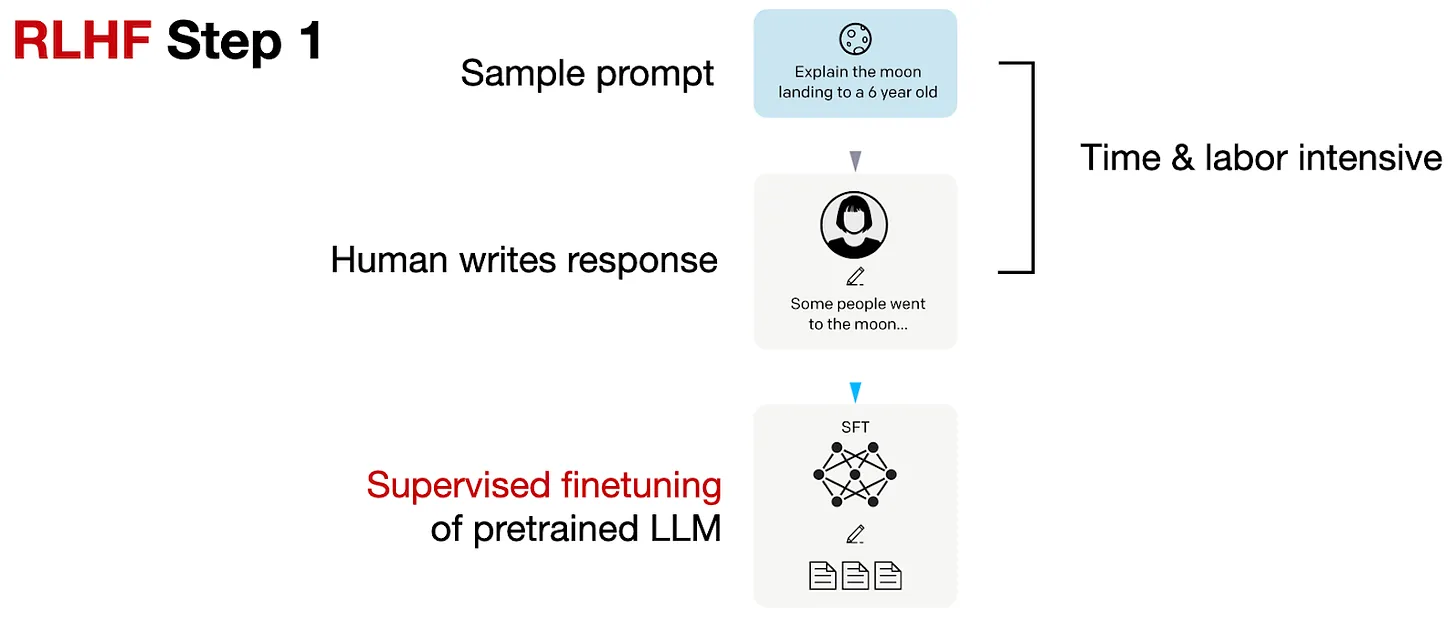
1. **Collecting Prompts and Human-Written Responses:**  
   A dataset is gathered where human experts write high-quality responses to various prompts.  
2. **Fine-Tuning the Base Model:**  
   The pretrained model is then fine-tuned on this dataset in a supervised manner. This is similar to standard language model training but with an emphasis on human-aligned outputs.

*Interactive Tip:*  
Imagine teaching a child by showing correct answers to homework problems—the model learns by example.

---

### Stage 2: Building a Reward Model
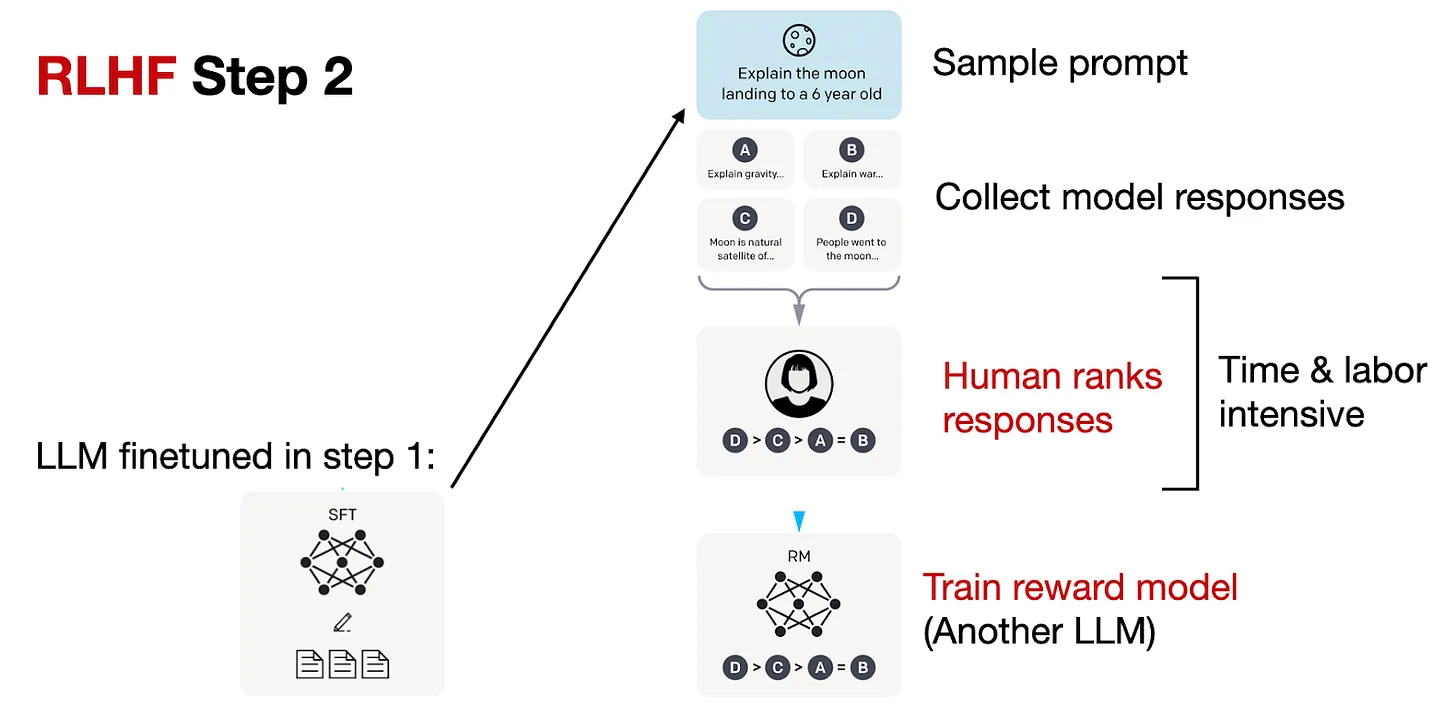
1. **Generating Multiple Responses:**  
   - The fine-tuned model generates several responses for each prompt.  
2. **Human Ranking:**  
   - Humans rank these responses according to quality, ease of understanding, or alignment with intended behavior.  
3. **Training the Reward Model:**  
   - The reward model (often derived from the fine-tuned model) is then trained on this ranked data to output a numerical score (reward) that reflects human preference.

* Tip:*  
Think of the reward model as a “taste tester” that scores various dishes; the higher the score, the better the dish aligns with the desired flavor.

>  Let's refer to te reward model as `RM` and the LLM from the supervised finetuning step as `SFT`. To turn the model from `RLHF Step 1` into a `reward model`, its output layer (t`he next-token classification layer`) is substituted with a regression layer, which features a single output node.
---

### Stage 3: RLHF Step 3: Finetuning via proximal policy optimization
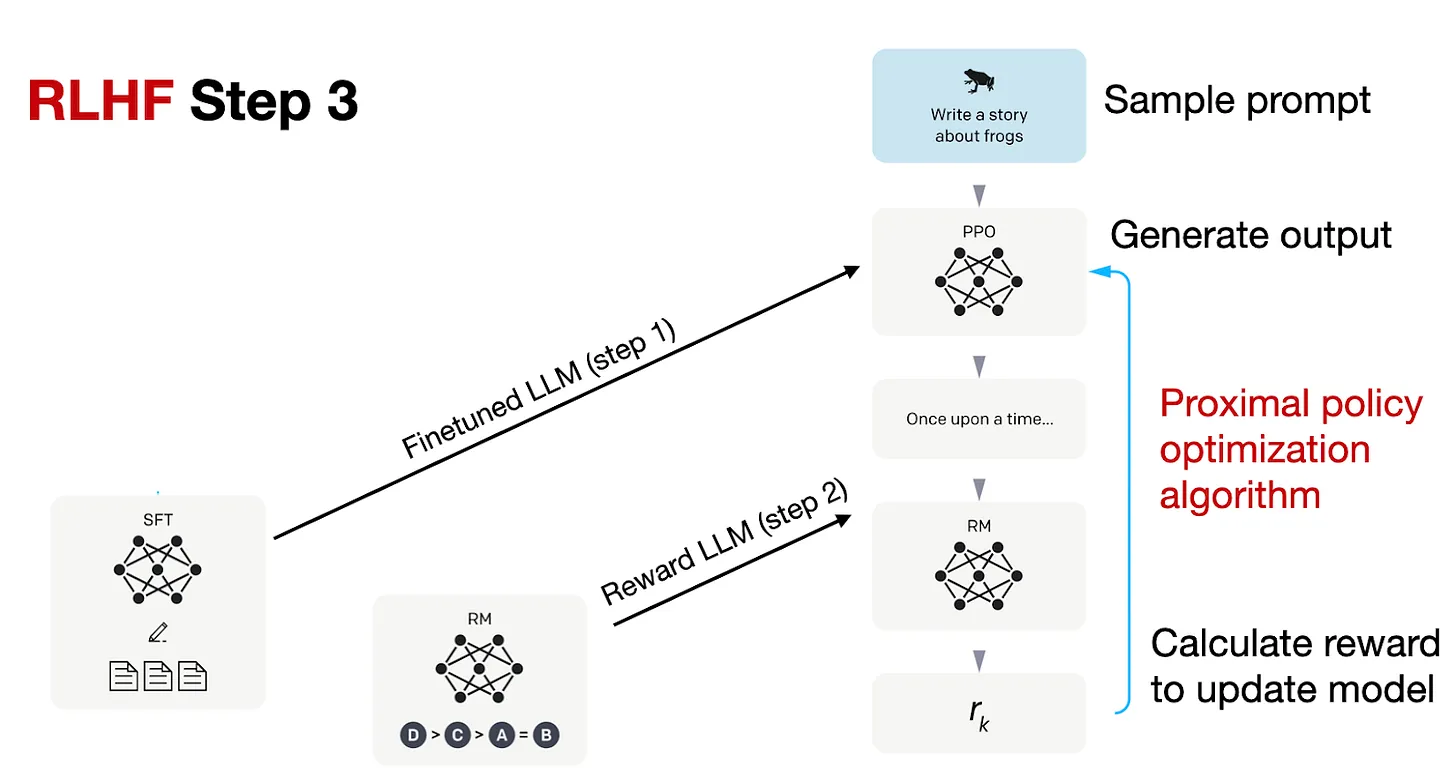
1. **Using the Reward Model for RL:**  
   The reward model’s scores guide further training. The model now acts as an RL agent, generating responses and receiving rewards.  
2. **Proximal Policy Optimization (PPO):**  
   PPO is used to update the model’s policy. It ensures that updates do not deviate too much from the original fine-tuned model, balancing exploration (trying new responses) and exploitation (using learned responses).

*Interactive Tip:*  
Imagine a student who tries different problem-solving methods; the ones that yield better results (as judged by a teacher) are reinforced, but the student is also encouraged to keep a balance so as not to forget the basics learned earlier.

---

###  Discussion Points

- **Why RLHF?**  
  RLHF addresses the challenge of defining an explicit reward function for complex tasks (like generating safe, engaging dialogue). Instead, human preferences are used as a guide.

- **Balancing Innovation and Stability:**  
  The PPO step includes a KL divergence term that prevents the model from straying too far from its initial fine-tuned behavior, ensuring that while it adapts, it does not forget its core language abilities.

- **Applications:**  
  RLHF is used in training state-of-the-art chatbots (e.g., ChatGPT, Claude) and can be applied to various domains—from conversational agents and summarization tasks to even robotics and computer vision.

---

### Summary

**RLHF Pipeline Recap:**  
1. **SFT:** Teaches the model through examples (human-written responses).  
2. **Reward Modeling:** Builds a scoring system that captures human judgments.  
3. **RL via PPO:** Uses these scores to refine the model’s responses in an iterative, balanced manner.





<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">RLHF Pipeline Visual</h2>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">===========================================================================
                        RLHF PIPELINE (3 Stages)
===========================================================================

STAGE 1: Supervised Fine-Tuning (SFT)
--------------------------------------
  [Pretrained LLM]
        |
        v
  +---------------------+      +-------------------------+
  | Human-written        | ---&gt; | Fine-tune on supervised  |
  | demonstration data   |      | (prompt, response) pairs |
  +---------------------+      +-------------------------+
                                         |
                                         v
                                  [SFT Model (pi_SFT)]

STAGE 2: Reward Model Training
--------------------------------------
  [SFT Model] --generates--&gt; [Multiple responses per prompt]
        |                              |
        v                              v
  +---------------------+      +-------------------------+
  | Humans RANK          | ---&gt; | Train Reward Model (RM)  |
  | responses by quality |      | on pairwise preferences  |
  +---------------------+      | Loss: -log(sig(r_w - r_l))|
                                +-------------------------+
                                         |
                                         v
                                  [Reward Model r(x,y)]

STAGE 3: RL Fine-Tuning with PPO
--------------------------------------
  [SFT Model] --copy--&gt; [Policy Model pi_theta]
        |                       |
        |                  generates response y
        |                       |
        v                       v
  +-----------+     +---------------------------+
  | Reference |     | Reward Model scores r(x,y)|
  | Model     |     +---------------------------+
  | (frozen)  |                |
  +-----------+                v
        |          +----------------------------+
        |          | PPO Update:                 |
        +--------&gt; | maximize r(x,y)             |
                   | - beta * KL(pi || pi_ref)   |
                   +----------------------------+
                               |
                               v
                      [Aligned Model pi*]

===========================================================================
  Key Insight: KL divergence penalty prevents &quot;reward hacking&quot; --
  the model cannot drift too far from the original SFT behavior.
===========================================================================
</code></pre>
<div style="margin:14px 0;padding:12px 16px;background:#2d251e;border-left:5px solid #caa56c;border-radius:14px;border:1px solid #56442f;color:#f1e5d0;line-height:1.75;"><p style="margin:6px 0;line-height:1.75;"><strong>Interview Tip:</strong> When asked &quot;Walk me through the RLHF pipeline,&quot; use this 3-stage framework:</p></div>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>SFT</strong> = Learn from expert demonstrations (imitation learning)</li>
<li style="margin:6px 0;"><strong>Reward Model</strong> = Learn a scoring function from human preferences (Bradley-Terry model)</li>
<li style="margin:6px 0;"><strong>PPO</strong> = Optimize the policy against the reward model with a KL constraint (prevents collapse)</li>
</ol>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;">Lamma-chat 2  RLHF</h4>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Feef9ddfa-657d-4784-9e87-371e7617143d_1600x768.png" alt="" /></p>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">2. Reward Modeling Differences</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F17d06b15-e1de-49df-907c-65dc26d1fc21_1444x986.png" alt="" /></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>InstructGPT Approach:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Single Reward Model:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Human labelers rank 4–9 model outputs per prompt.</li>
<li style="margin:6px 0;">All “k choose 2” pairwise comparisons are used to train one reward model via a cross‑entropy loss.</li>
</ul>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Llama‑2‑chat Approach:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Dual Reward Models:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Llama‑2‑chat trains <strong>two separate reward models</strong>—one for <em>helpfulness</em> and one for <em>safety</em>.</li>
<li style="margin:6px 0;">The final reward used for policy optimization is a <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">linear combination of these two scores</code>.</li>
<li style="margin:6px 0;"></li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Binary Comparisons with Margin Labels:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Instead of ranking many responses at once, each labeling round in Llama‑2 presents only two responses (A and B).</li>
<li style="margin:6px 0;">Along with the binary preference (A &lt; B), a <strong>margin label</strong> is collected. This margin indicates how much better one response is compared to the other (ranging from “significantly” to “negligibly” better).</li>
<li style="margin:6px 0;">The margin is incorporated into the <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">ranking loss</code> via a discrete function m(r).</li>
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">A higher margin forces the loss to be larger (i.e. larger gradients) when the difference is small—pushing the model to make more substantial adjustments when needed.</code></li>
</ul>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Components</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">• rθ(x,y): scalar reward score for response y given prompt x.
• σ: Logistic sigmoid function converting the difference into a [0, 1] score.
• yc: Preferred (chosen) response by human annotators.
• yr: Rejected response by human annotators.
</code></pre>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Detailed Explanation</h3>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>InstructGPT Loss Function:</strong><br />
The loss function is designed to push the reward model to assign a higher score to the preferred response ycy_c compared to the rejected response yry_r. It is given by:</p></p>

$$
L=−E(x,yc,yr)[log⁡(σ(rθ(x,yc)−rθ(x,yr)))]L = -\mathbb{E}<em>{(x, y_c, y_r)}\left[\log\left(\sigma\left(r</em>\theta(x, y_c) - r_\theta(x, y_r)\right)\right)\right]
$$

<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Here, the sigmoid σ\sigma converts the difference $$  rθ(x,yc)−rθ(x,yr)r_\theta(x, y_c) - r_\theta(x, y_r) $$ into a probability between 0 and 1.</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Llama‑2 Loss Function with Margin:</strong><br />
Llama‑2 modifies the above formulation by adding a margin function m(r) that acts as <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">a discrete indicator of how strong the human preference is between two responses</code>. The modified loss becomes:</p>
</li>
</ol></p>

$$
L=−E(x,yc,yr)[log⁡(σ(rθ(x,yc)−rθ(x,yr)−m(r)))]L = -\mathbb{E}<em>{(x, y_c, y_r)}\left[\log\left(\sigma\left(r</em>\theta(x, y_c) - r_\theta(x, y_r) - m(r)\right)\right)\right]
$$

<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">The margin m(r) can be seen as a “penalty” term:
-   If human annotators indicate that the preferred response is only slightly better than the rejected one, m(r) might be small.
-   If the preferred response is significantly better, m(r) is larger, thereby forcing a wider gap between rθ(x,yc)r_\theta(x, y_c) and rθ(x,yr)r_\theta(x, y_r) to reduce the loss.
</code></pre>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">This additional term ensures that the model not only learns to rank responses correctly but also adjusts the strength of its learning signal based on the degree of preference.</li>
</ul>
<ol start="3">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Impact on Training:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Without Margin (InstructGPT):</strong> The loss treats every pairwise difference equally.</li>
<li style="margin:6px 0;"><strong>With Margin (Llama‑2):</strong> The loss function is <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">more sensitive</code> to the relative quality of responses as judged by humans. Larger margins yield larger gradients, prompting more significant updates to the model weights when the preferred response is much better than the rejected one.</li>
</ul>
</li>
</ol>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">This nuanced approach helps Llama‑2 better capture the subtleties in human feedback, potentially leading to improved alignment in both helpfulness and safety of the model’s responses.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Insight:_<br />
Imagine comparing two essays. In the InstructGPT setup, you’d rank several essays and all possible pairs would contribute to the training. In Llama‑2‑chat, you simply compare two essays at a time—and also note how much one outperforms the other, which gives a more nuanced signal.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">3. Reinforcement Learning Strategy</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Llama‑2‑chat:</strong>
<img src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fd187fa03-982c-4818-bbd7-833d2ef10386_1298x864.png" alt="" /></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Iterative and Multi‑Stage RLHF:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The training process evolves through multiple stages (RLHF‑V1 to RLHF‑V5), where the<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;"> reward models are periodically updated</code> based on the errors emerging from the Llama‑2‑chat model.</li>
<li style="margin:6px 0;"></li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Rejection Sampling:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Rejection sampling</strong> is introduced: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">at each training iteration</code>, the model generates K responses, and the one with the highest combined reward (helpfulness + safety) is chosen for the gradient update.</li>
<li style="margin:6px 0;">This process ensures that, at each update step, the model learns only from the “best” responses.</li>
<li style="margin:6px 0;"></li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Final PPO Stage:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">I<strong>n the final stage, PPO is applied again to further refine the policy</strong>. Empirical results suggest that using PPO at the end outperforms a pipeline that relies solely on rejection sampling.</li>
</ul>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Insight:_<br />
Think of rejection sampling as a “talent show” where multiple candidates perform and only the best performer is selected to influence future training. Then, the final PPO step fine‑tunes the model’s behavior based on these high‑quality selections.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">4. Performance Impact</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Meta AI’s experiments show that:</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Iterative Updates and Dual Reward Models</strong> help improve both the <em>helpfulness</em> and <em>harmlessness</em> (safety) of the final model.</li>
<li style="margin:6px 0;"><strong>Combining Rejection Sampling with PPO</strong> leads to better performance than using either method alone.
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">For example, a model trained with PPO in the final stage (RLHF‑v5 with PPO) outperforms one that uses only rejection sampling.
<img src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F334cb151-1c0d-45e0-ad66-ef4509d022c7_804x748.png" alt="" /></li>
</ul>
</li>
</ul>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>Understanding Target Modules in LLaMA Models</strong></h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>What Are These Modules?</strong></h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">The list of target modules:</p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">[&quot;q_proj&quot;, &quot;k_proj&quot;, &quot;v_proj&quot;, &quot;up_proj&quot;, &quot;down_proj&quot;, &quot;o_proj&quot;, &quot;gate_proj&quot;]
</code></pre>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">These refer to <strong>projection layers</strong> in transformer-based models like LLaMA. They play a key role in:</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Attention Mechanism</strong> (q_proj, k_proj, v_proj, o_proj)</li>
<li style="margin:6px 0;"><strong>Feed-Forward Network (MLP)</strong> (up_proj, down_proj, gate_proj)</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">These layers handle transformations that help the model <strong>understand and generate text</strong> efficiently.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>Breakdown of Each Module</strong></h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>1. Attention Mechanism (Focus on Relevant Text)</strong></h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">These layers are responsible for computing attention scores and deciding which words in a sentence are most important.</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>q_proj (Query Projection):</strong> Converts input into query vectors to determine which tokens to focus on.</li>
<li style="margin:6px 0;"><strong>k_proj (Key Projection):</strong> Converts input into key vectors, which are compared with queries to compute attention scores.</li>
<li style="margin:6px 0;"><strong>v_proj (Value Projection):</strong> Converts input into value vectors, which contain the actual information to be passed forward.</li>
<li style="margin:6px 0;"><strong>o_proj (Output Projection):</strong> Merges the attention results from multiple attention heads into a single output.</li>
</ul>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong> In &quot;The cat sat on the mat,&quot; the model decides how much attention &quot;sat&quot; should give to &quot;cat&quot; by comparing queries (q_proj) and keys (k_proj).</p>
</blockquote>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>2. Feed-Forward Network (Enhancing Expressiveness)</strong></h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">After attention, each token passes through a feed-forward network to learn more complex patterns.</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>up_proj (Up Projection):</strong> Expands the input size (e.g., from 4096 to 11008) to capture richer features.</li>
<li style="margin:6px 0;"><strong>gate_proj (Gate Projection):</strong> Works as a filter, controlling which information from up_proj should be kept (LLaMA uses a gated approach for better performance).</li>
<li style="margin:6px 0;"><strong>down_proj (Down Projection):</strong> Reduces the size back to match the model’s hidden size, preparing it for the next layer.</li>
</ul>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong> After attending to &quot;cat&quot; in &quot;The cat sat on the mat,&quot; these layers help refine the understanding of &quot;sat&quot; in the sentence.</p>
</blockquote>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>Why Are These Important?</strong></h2>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Critical for Model Efficiency</strong> – They determine how well the model understands relationships between words.</li>
<li style="margin:6px 0;"><strong>Targeted in Fine-Tuning</strong> – Techniques like <strong>LoRA (Low-Rank Adaptation)</strong> modify these layers to efficiently train models without updating all parameters.</li>
<li style="margin:6px 0;"><strong>Unique to LLaMA</strong> – The <strong>gate_proj</strong> layer introduces a <strong>gated mechanism (SwiGLU activation)</strong>, making LLaMA more expressive than traditional transformers.</li>
</ol>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The <strong>gate_proj layer is unique</strong> to LLaMA and makes it more expressive than standard transformers.</li>
</ul>
</blockquote>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>Comparing Different Models</strong></h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Different models have different names for these layers.</p>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Model</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Target Modules Used</th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>LLaMA</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">q_proj, k_proj, v_proj, o_proj, up_proj, down_proj, gate_proj</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Falcon 7B</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">query_key_value, dense, dense_h_to_4h, dense_4h_to_h</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>OPT-6.7B</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">q_proj, v_proj</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Flan-T5</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">q, v</td>
</tr>
</tbody>
</table>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Fine-Tuning with Preference Alignment:</h3>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Why Traditional SFT Falls Short</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Supervised Fine-Tuning (SFT) is great for specific tasks but fails to adapt to diverse human preferences or rare situations.</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>What is Preference Alignment?</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">A method to teach AI systems to reflect human preferences by using feedback from humans or AI.</li>
<li style="margin:6px 0;">Focuses on making AI outputs relatable and authentic.</li>
</ul>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>How to Align Models?</strong></h4>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Create a Preference Dataset</strong>: Collect and format data based on what humans value.</li>
</ol>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Benefits of Preference Alignment</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Makes chat models more conversational.</li>
<li style="margin:6px 0;">Helps creative models generate authentic content.</li>
<li style="margin:6px 0;">Aligns AI assistants with specific tones, e.g., empathetic customer support.</li>
</ul>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Preference Data: Key Concepts and Benefits</h3>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>What is Preference Data?</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Unlike standardized instruction datasets, preference data involves multiple responses to an instruction, ranked based on human or AI feedback.</li>
<li style="margin:6px 0;"><strong>Key Feature</strong>: Each instruction has:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">A <strong>preferred response</strong> (desired behavior).</li>
<li style="margin:6px 0;">A <strong>rejected response</strong> (undesired behavior).</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Dataset Format</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Objective</strong>: Train the model to prioritize generating preferred responses over rejected ones.</li>
<li style="margin:6px 0;"><strong>Example</strong>:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Instruction</strong>: Tell me a joke about octopuses.</li>
<li style="margin:6px 0;"><strong>Chosen Answer</strong>: Why don’t octopuses play cards in casinos? Because they can’t count past eight.</li>
<li style="margin:6px 0;"><strong>Rejected Answer</strong>: How many tickles does it take to make an octopus laugh? Ten tickles.</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Why Are Rejected Responses Important?</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">They define the undesired behavior to be avoided during model training.</li>
<li style="margin:6px 0;">Without them, the dataset would merely be an instruction set, limiting its refinement capabilities.</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Advantages of Preference Datasets Over SFT</strong></h4>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Flexibility</strong>: Adaptable to subjective human judgments and complex scenarios.</li>
<li style="margin:6px 0;"><strong>Behavior Elimination</strong>: Helps eliminate undesired outputs by training against rejected responses.</li>
<li style="margin:6px 0;"><strong>Better Human Alignment</strong>: Produces models that align outputs with nuanced human preferences.</li>
</ol>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Reinforcement Learning with Human Feedback (RLHF): Key Concepts</h3>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Core Components of RLHF</strong></h4>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Reward Model Learning</strong>:</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Purpose</strong>: Learn a reward function from human feedback instead of using a predefined one.</li>
<li style="margin:6px 0;"><strong>Process</strong>:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Present multiple answers to humans for a given task.</li>
<li style="margin:6px 0;">Train the reward model based on human preferences, often using techniques like the Bradley-Terry model to map preferences to utility.</li>
</ul>
</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Policy Optimization</strong>:</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Purpose</strong>: Improve the model’s behavior using the learned reward model.</li>
<li style="margin:6px 0;"><strong>Process</strong>:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Use standard reinforcement learning (RL) algorithms to maximize predicted rewards.</li>
<li style="margin:6px 0;">Policies iteratively adapt to become more aligned with human preferences.</li>
</ul>
</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Iterative Improvement</strong>:</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Purpose</strong>: Continuously refine the reward model and policy through human feedback.</li>
<li style="margin:6px 0;"><strong>Process</strong>:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Improved policies generate new behaviors.</li>
<li style="margin:6px 0;">These behaviors are evaluated by humans, further training the reward model.</li>
</ul>
</li>
</ul>
</li>
</ol>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Handling Human Feedback Costs</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Key Innovation</strong>: RLHF reduces reliance on continuous human supervision by:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Using <strong>asynchronous</strong> and <strong>sparse feedback</strong>.</li>
<li style="margin:6px 0;">Training a reward model as a proxy for human preferences, enabling independent reinforcement learning without human input at every step.</li>
</ul>
</li>
</ul>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Example: Proximal Policy Optimization (PPO) in RLHF</strong></h4>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781836200079/files/Images/B31105_06_04.png" alt="" /></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Overview</strong>:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Reward model scores text generated by the model.</li>
<li style="margin:6px 0;">Includes KL-divergence regularization to maintain token distribution similar to the pre-trained model.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Impact</strong>:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Allows the model to retain pre-trained knowledge while aligning its output with human preferences.</li>
</ul>
</li>
</ul>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Challenges of RLHF</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Iterative Nature</strong>: Computationally expensive and potentially unstable.</li>
<li style="margin:6px 0;"><strong>Underperformance</strong>: Despite theoretical advantages, RLHF can experimentally lag behind simpler methods like Direct Preference Optimization (DPO).</li>
</ul>



### Direct Preference Optimization (DPO): 
![](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781836200079/files/Images/B31105_06_05.png)
> The objective of DPO is the same as RLHF: improve the alignment of language models to human preferences
#### **What is DPO?**
- **Introduced By**: Rafailov et al., 2023.
- **Purpose**: Streamlines preference learning as an alternative to RLHF by removing the need for a separate reward model and reinforcement learning (RL) algorithms.
- **Core Insight**: Reformulates the learning problem to directly optimize the policy using a mathematical expression for reward maximization with a KL-divergence constraint.
- At the beginning of the fine-tuning process, an exact copy is done for the language model (LM) that is being trained, and its trainable parameters are frozen.
- For each datapoint, the chosen and rejected responses are scored by both the trained and the frozen language model. This score is the product of the probabilities associated with the desired response token for each step.


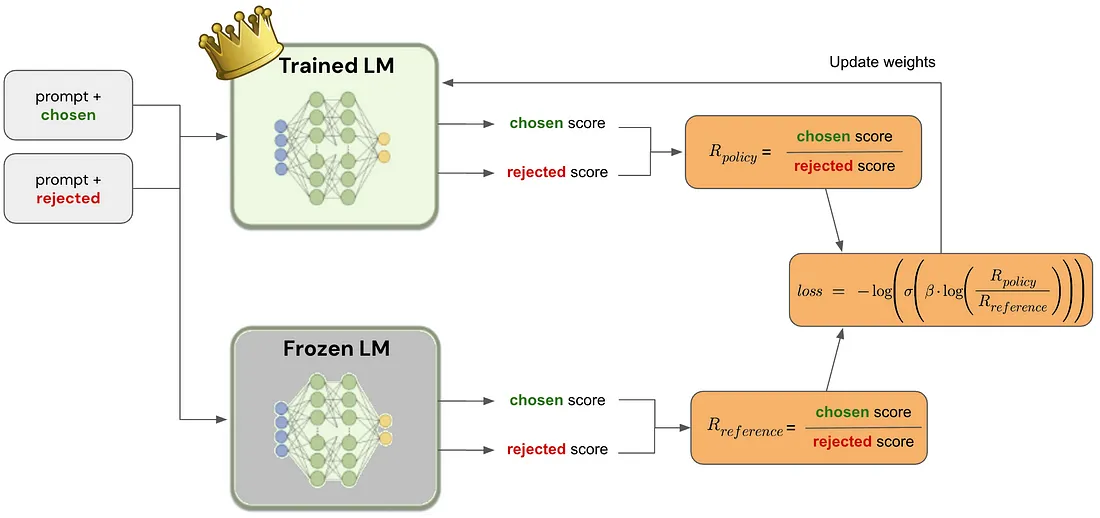
---


#### **How Does DPO Work?**
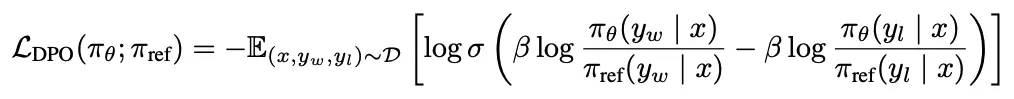
1. **Optimization**:
   - Uses **binary cross-entropy loss** directly on the model’s output probabilities.
   - Encourages higher probabilities for **preferred responses** and lower for **non-preferred responses**.
2. **Reference Model**:
   - Maintains similarity to a frozen reference model through a **beta parameter** (common value: 0.1).
   - **Beta = 0**: No influence from the reference model, allowing greater divergence.
3. **Efficiency**:
   - Operates without RL techniques like Proximal Policy Optimization (PPO).
   - Optimized using standard gradient descent, avoiding the need for sampling during training.
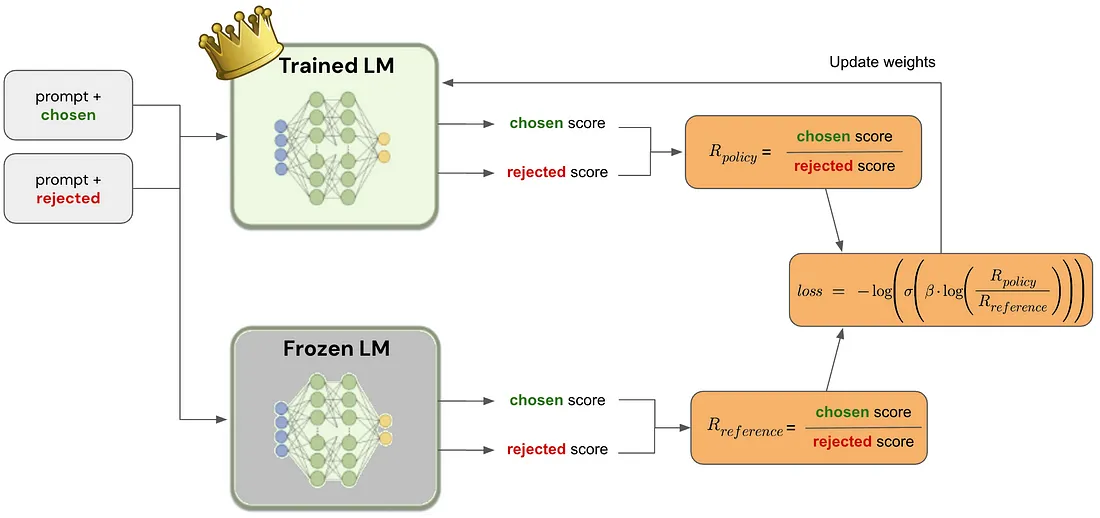
---

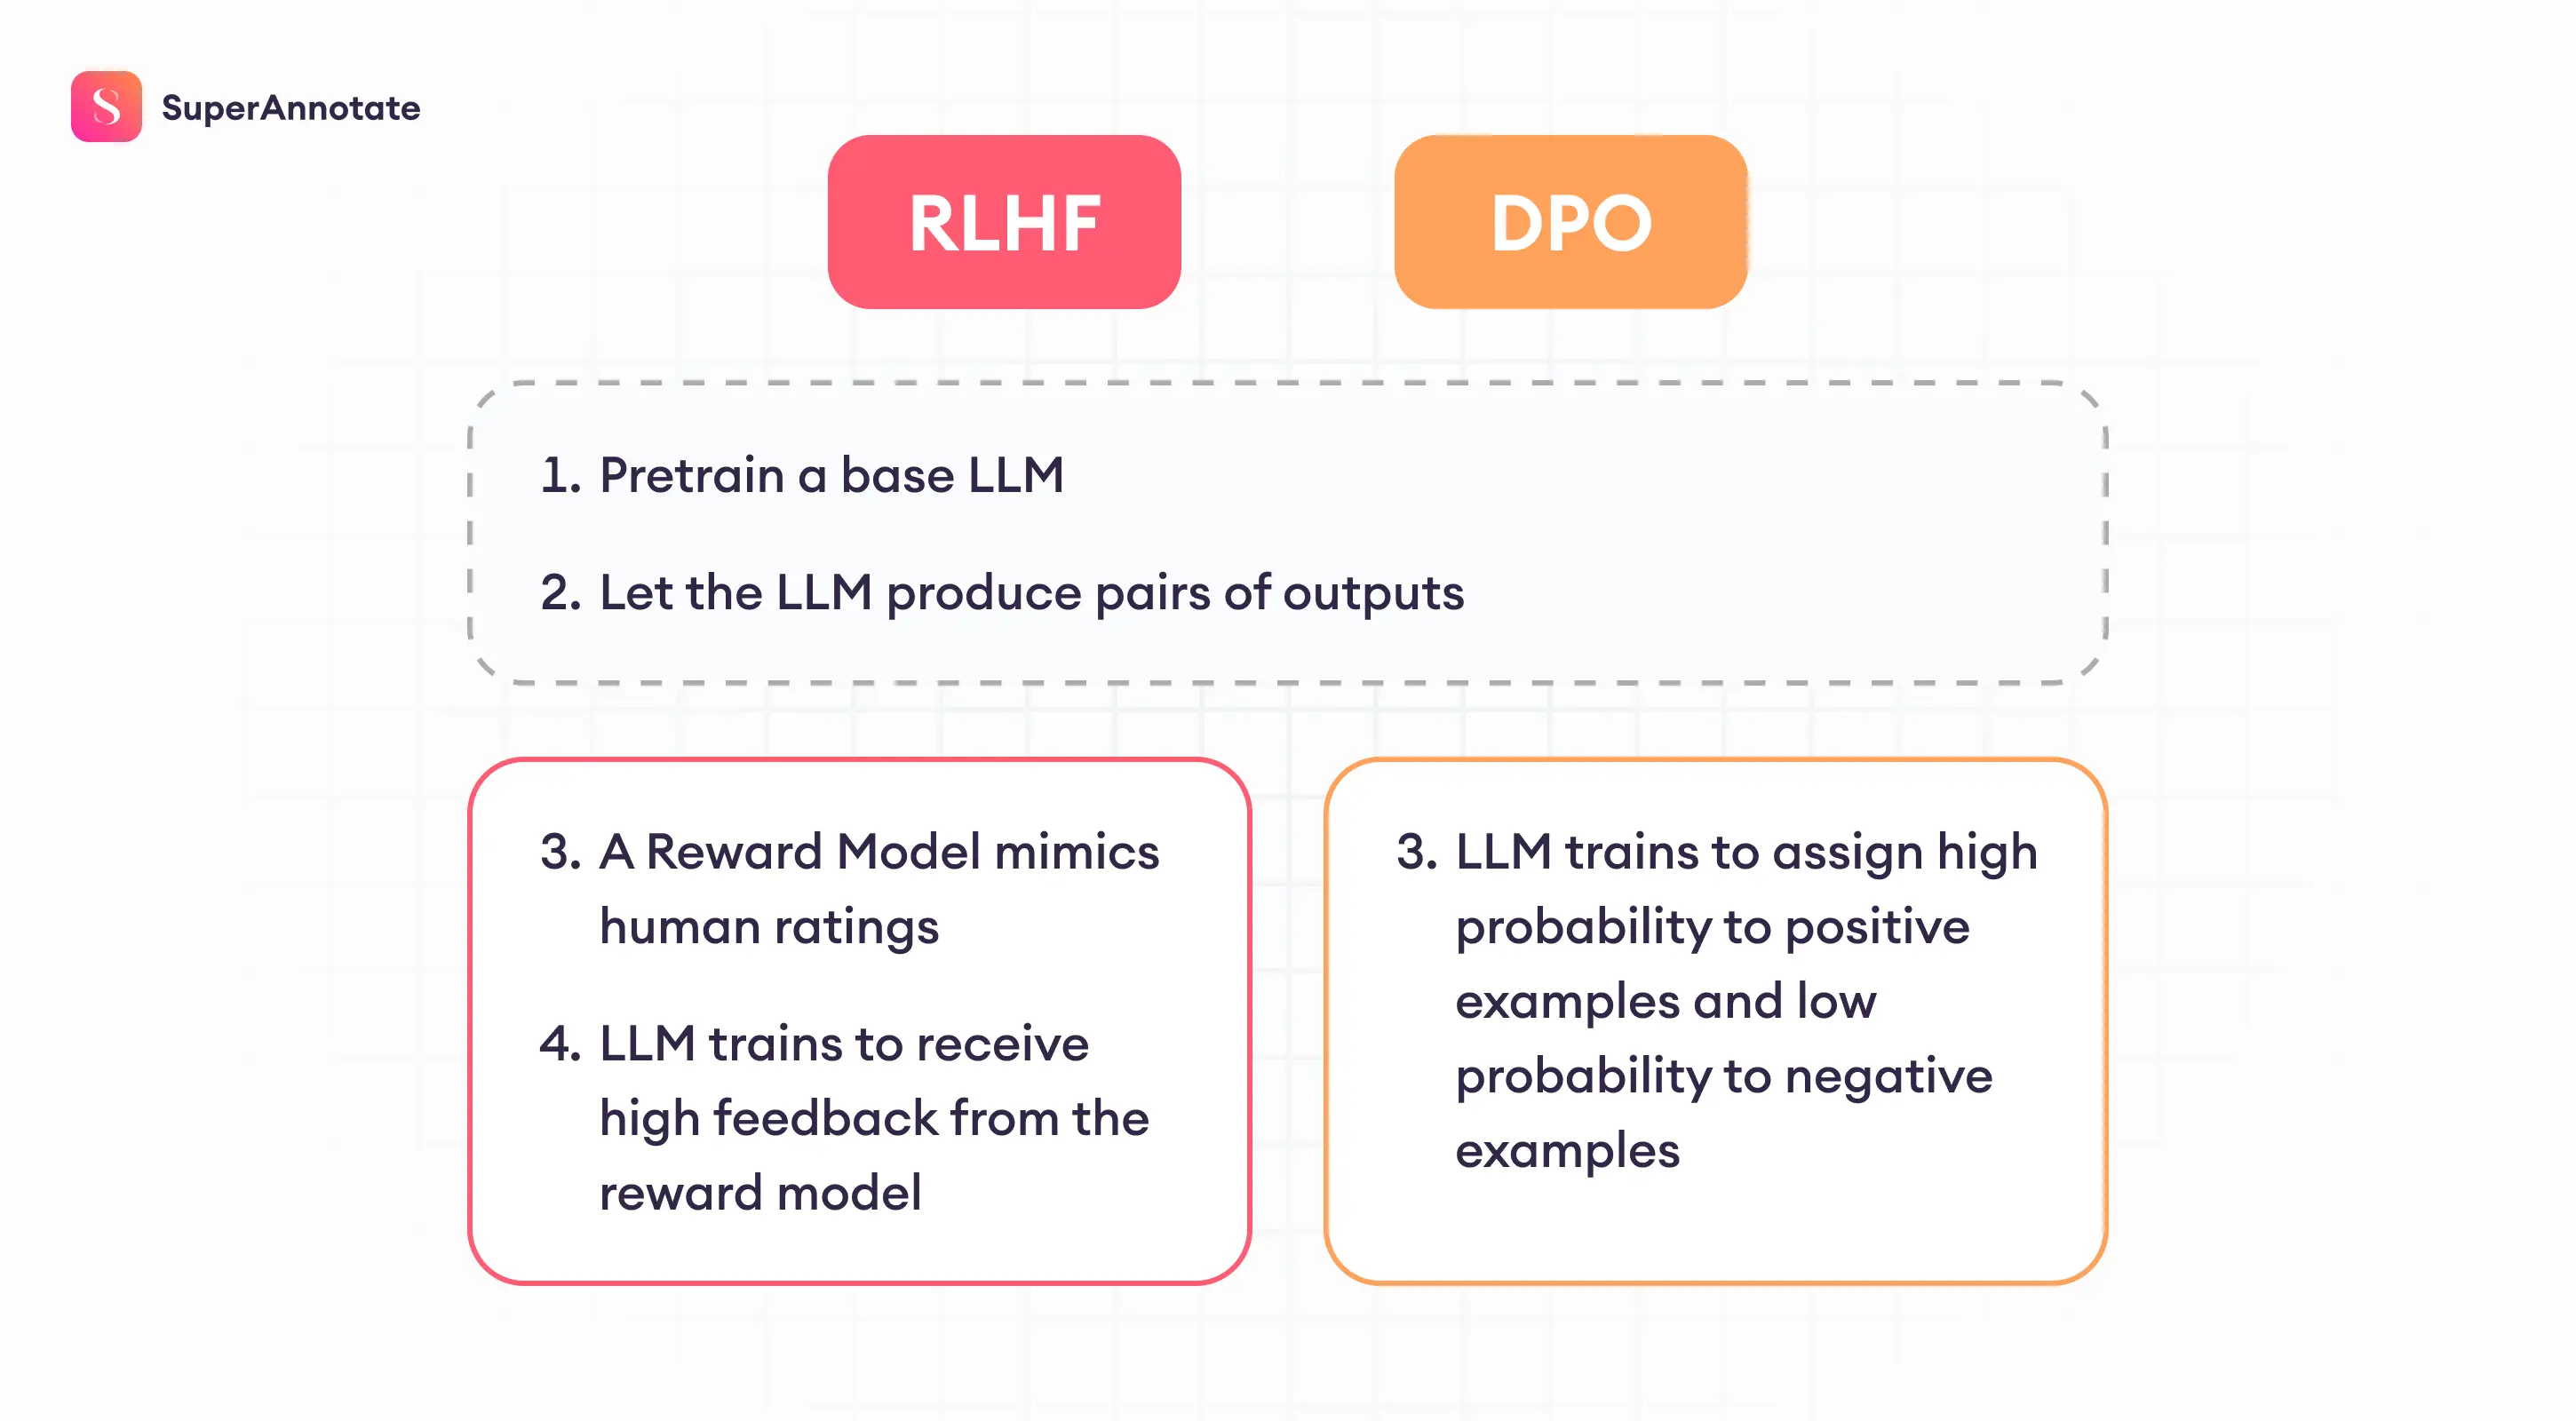

> DPO uses existing completions to score how well the model predicts them and shifts preference toward the chosen one. The model doesn’t generate anything during training — it only generates responses at inference time using its improved internal preferences.

- https://medium.com/@mauryaanoop3/dpo-fine-tuning-for-enhanced-language-model-performance-466fec349a5e

<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Advantages</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Simplicity</strong>:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Removes complex RL algorithms and separate reward models.</li>
<li style="margin:6px 0;">Reduces engineering complexity.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Efficiency</strong>:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Lower computational cost—ideal for teams with limited resources.</li>
<li style="margin:6px 0;">Saves VRAM when used with LoRA or QLoRA (only one model needs to be loaded).</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Stability</strong>:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Less sensitive to hyperparameters.</li>
<li style="margin:6px 0;">Matches or surpasses RLHF performance in most cases.</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>Drawbacks</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Still requires <strong>paired preference data</strong>, which can be costly and time-consuming to collect.</li>
<li style="margin:6px 0;">Lacks the <strong>theoretical guarantees</strong> of RL-based methods.</li>
<li style="margin:6px 0;">RLHF may perform better in large-scale, complex tasks with millions of preference samples.</li>
</ul>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><strong>When to Use DPO</strong></h4>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Best suited for projects requiring simplicity, efficiency, and stability.</li>
<li style="margin:6px 0;">Ideal for small to medium-scale applications with limited resources.</li>
<li style="margin:6px 0;">May not replace RLHF in environments requiring dynamic, iterative improvements.</li>
</ul>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">DPO vs PPO: Head-to-Head Comparison</h3>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Aspect</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">PPO (RLHF)</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">DPO</th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Reward Model</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Requires separate reward model</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">No reward model needed (implicit)</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Training Pipeline</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">3-stage: SFT -&gt; RM -&gt; PPO</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">2-stage: SFT -&gt; DPO</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Models in Memory</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">4 models (policy, reference, reward, value)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">2 models (policy, reference)</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Optimization</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">RL-based (policy gradient)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Supervised (cross-entropy on preferences)</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Stability</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Can be unstable, sensitive to hyperparams</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">More stable, fewer hyperparams</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Compute Cost</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">High (online generation + RL loop)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Low (offline, no generation during training)</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Scalability</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Better at very large scale (GPT-4 class)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Better for small-to-medium scale</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Data</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Can use online data (generate during training)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Requires offline preference pairs</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Theoretical Basis</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Well-established RL theory</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Closed-form solution of RLHF objective</td>
</tr>
</tbody>
</table>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;">DPO Loss Function Intuition</h4>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">L_DPO = -log sigmoid( beta * [ log(pi(y_w|x)/pi_ref(y_w|x)) 
                              - log(pi(y_l|x)/pi_ref(y_l|x)) ] )

Where:
  pi      = current policy (model being trained)
  pi_ref  = frozen reference model (copy of SFT model)
  y_w     = preferred (winning) response
  y_l     = rejected (losing) response
  beta    = temperature controlling deviation from reference
</code></pre>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Intuition:</strong> DPO increases the relative log-probability of preferred responses vs rejected ones, while staying close to the reference model. The beta parameter controls how much the model can deviate -- higher beta means stricter adherence to the reference.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Interview Key Point:</strong> DPO proves that the optimal policy for the RLHF objective has a closed-form solution, so you can skip the reward model entirely and directly optimize the policy on preference data.</p>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h5>To create preference data for fine-tuning language models, several public datasets are available:</h5>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">OpenAI WebGPT Comparisons: This dataset provides comparisons, including a question, a pair of model answers, and human-rated preference scores for each answer.</li>
<li style="margin:6px 0;">OpenAI Summarization: This dataset offers text summarization examples, consisting of human-written responses and human-rated model responses.</li>
<li style="margin:6px 0;">Reddit ELI5: Sourced from Q&amp;A subreddits, this dataset contains questions, answers, and scores.</li>
<li style="margin:6px 0;">Human ChatGPT Comparison Corpus (HC3): This dataset provides human and ChatGPT answers for various questions.</li>
</ul>



## Odds Ratio Preference Optimization (ORPO)

##### 1. The Problem with Traditional SFT

**Traditional Supervised Fine-Tuning (SFT):**

-   **Objective:** Maximizes the likelihood of generating target tokens by minimizing the negative log-likelihood (NLL).
-   **Limitation:** Although SFT makes the model generate fluent text, it does not include any built-in mechanism to **discourage disfavored responses**. In other words, the loss function only rewards the right answer but never explicitly penalizes an answer that humans would reject.

**Odds Ratio Preference Optimization (ORPO)** is an innovative fine-tuning technique that integrates supervised fine-tuning (SFT) and preference alignment into a single, unified process. This approach enhances efficiency and performance compared to traditional methods like Reinforcement Learning with Human Feedback (RLHF) or Direct Preference Optimization (DPO).

**Understanding ORPO**

Traditional alignment methods, such as DPO, typically involve two separate stages:

1.  **Supervised Fine-Tuning (SFT):** Adapts the model to a specific domain and format.
2.  **Preference Alignment:** Aligns the model's outputs with human preferences.
----------

## 2. Introducing the Odds Ratio

ORPO tackles this limitation by using the concept of **odds** and comparing them between two responses. Let’s break it down:

### A. **Odds of Generating a Sequence**

-   **Definition:**  
    The odds of generating a sequence ( y ) given an input ( x ) can be defined as:
    
    $$ [ \text{Odds}(y|x) = \frac{P(y|x)}{1 - P(y|x)} ] $$
    
    This value tells you how much more likely the model is to output the sequence ( y ) compared to not outputting it.
    
-   **Interpretation:**
    
    -   `A higher odds` value implies the model is "confident" in generating that sequence.
    -   It’s a way to quantify model preference beyond the raw probability.

### B. **Odds Ratio (OR) Between Responses**

-   **Favored vs. Disfavored:**  
    ORPO considers two responses for a given prompt:
    
    -   **Favored response (( y_w ))** – the one humans prefer.
    -   **Disfavored response (( y_l ))** – the one that is rejected.
-   **Odds Ratio Calculation:**
    
    $$ [ \text{OR} = \frac{\text{Odds}(y_w|x)}{\text{Odds}(y_l|x)} ]  $$
    
    This ratio directly compares how much more likely the model is to generate the favored response compared to the disfavored one.
    

**Visualization:**

```
               [Input: x]
                  /  \
     Favored: y_w    Disfavored: y_l
         |                 |
   Compute Odds      Compute Odds
      O_w = P(y_w|x)/(1-P(y_w|x))
      O_l = P(y_l|x)/(1-P(y_l|x))
                  |
         Odds Ratio = O_w / O_l

```

## 3. Designing the Loss Function

### A. **Standard SFT Loss**

-   **Formula:**  
     $$ L_{\text{SFT}} = -\log P(y|x)  $$
    
    This encourages the model to generate the correct tokens as seen in the training data.
    

### B. **Penalty Term Based on Odds Ratio**

-   **Objective:**  
    To **penalize the model** if the odds ratio between the favored and disfavored responses is `not large enough`.
    
-   **Intuition:**  
    If the favored response isn’t substantially more likely than the disfavored one, the model should be “punished” so that it learns to differentiate better.
    
-   **How It Works:**
    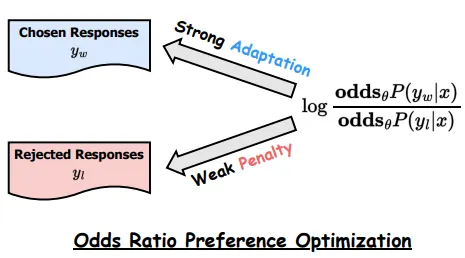
   
        
    2.  **Sigmoid Smoothing:**
        
       ` To make the gradient smoother and prevent abrupt changes during optimization, the log odds ratio is passed through a sigmoid function`. This keeps the penalty continuous and differentiable.
        
-   **Penalty Term  $$ (( L_{\text{OR}} ))  $$:**  
    While the exact formulation may vary, the idea is:
    
     $$L_{\text{OR}} = \text{sigmoid} \left(\log\frac{\text{Odds}(y_w|x)}{\text{Odds}(y_l|x)}\right) $$
    
    This term increases (i.e., the penalty becomes larger) when the log odds ratio is low.
    

### C. **Overall ORPO Loss Function**

-   **Combined Loss:**  
    ORPO uses a weighted sum of the standard SFT loss and the odds ratio penalty:
    
     $$ L_{\text{total}} = L_{\text{SFT}} + \lambda \cdot L_{\text{OR}} $$
    
    Where:
        -  `Lambda`     is a hyperparameter that controls the strength of the penalty.
    -   A higher  lambda forces the model to focus more on differentiating between favored and disfavored responses.

----------

## 4. Summary of ORPO’s Approach

1.  **Traditional SFT lacks an explicit penalty for disfavored outputs.**  
    ORPO fills this gap by incorporating a new penalty term.
    
2.  **Odds and Odds Ratio Calculation:**
    
    -   **Odds:** Measures how likely a response is generated.
    -   **Odds Ratio:** Compares the favored (( y_w )) and disfavored (( y_l )) outcomes.
3.  **Loss Function Composition:**
    
    -   **SFT Loss:** Maintains general language modeling capabilities.
        
    -   **Odds Ratio Penalty (( L_{\text{OR}} )):** Encourages the model to prefer the favored responses.
        
    -   **Combined Objective:**
        
         $$[ L_{\text{total}} = L_{\text{SFT}} + \lambda \cdot L_{\text{OR}} ] $$
        
   

<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">KTO - Kahneman-Tversky Optimization</h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Paper:</strong> Ethayarajh et al., 2024 - &quot;KTO: Model Alignment as Prospect Theoretic Optimization&quot;</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Core Idea</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">KTO is inspired by <strong>Kahneman and Tversky's Prospect Theory</strong> from behavioral economics. The key insight: <strong>humans don't evaluate outcomes on an absolute scale -- they evaluate them relative to a reference point, and losses loom larger than gains.</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">KTO applies this asymmetry to LLM alignment:</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Generating a <strong>bad response feels worse</strong> than generating a good response feels good</li>
<li style="margin:6px 0;">The loss function should reflect this human psychological bias</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Why KTO? The Data Problem</h3>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Data Requirement</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">RLHF/PPO</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">DPO</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">ORPO</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">KTO</th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Paired preferences (chosen vs rejected for SAME prompt)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>No</strong></td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Unpaired binary labels (thumbs up/down on individual responses)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">-</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">-</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">-</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Yes</strong></td>
</tr>
</tbody>
</table>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>This is KTO's biggest advantage:</strong> In practice, collecting paired preference data is expensive. It is much easier to get binary feedback (&quot;Was this response good or bad?&quot;) than pairwise comparisons (&quot;Which of these two responses is better?&quot;).</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">How KTO Works</h3>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">KTO Loss Function (simplified intuition):

For a GOOD response (y+):
  L = 1 - sigmoid(beta * [log(pi(y+|x)/pi_ref(y+|x)) - KL_term])
  --&gt; Reward the model for increasing probability of good responses

For a BAD response (y-):
  L = 1 - sigmoid(beta * [KL_term - log(pi(y-|x)/pi_ref(y-|x))])
  --&gt; Penalize the model MORE for not decreasing probability of bad responses
  --&gt; (loss aversion: lambda_bad &gt; lambda_good)

Where:
  KL_term = E[KL(pi || pi_ref)]  (estimated from batch)
  beta    = temperature parameter
  lambda  = loss aversion coefficient (asymmetric weighting)
</code></pre>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Key Components:</strong></p>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Reference Point:</strong> The KL divergence from the reference model serves as the &quot;status quo&quot;</li>
<li style="margin:6px 0;"><strong>Loss Aversion:</strong> Bad outputs are penalized more heavily than good outputs are rewarded (reflecting Prospect Theory)</li>
<li style="margin:6px 0;"><strong>No Pairing Required:</strong> Each example is processed independently -- no need to match chosen/rejected pairs</li>
</ol>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Advantages of KTO</h3>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Data Efficiency:</strong> Works with unpaired binary feedback -- much cheaper to collect at scale</li>
<li style="margin:6px 0;"><strong>Psychological Grounding:</strong> Loss function mirrors how humans actually perceive quality</li>
<li style="margin:6px 0;"><strong>Competitive Performance:</strong> Matches or exceeds DPO on standard benchmarks despite simpler data requirements</li>
<li style="margin:6px 0;"><strong>Scalable Annotation:</strong> Can use existing thumbs-up/thumbs-down data from production systems</li>
</ol>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Limitations of KTO</h3>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Newer Method:</strong> Less battle-tested than DPO or PPO in production</li>
<li style="margin:6px 0;"><strong>Hyperparameter Sensitivity:</strong> The loss aversion coefficient needs tuning</li>
<li style="margin:6px 0;"><strong>Theoretical Guarantees:</strong> Less well-understood convergence properties than DPO</li>
</ol>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Interview Key Point:</strong> KTO is the go-to method when you have <strong>binary feedback</strong> (good/bad) rather than <strong>pairwise preferences</strong> (A is better than B). Think of it as &quot;DPO for unpaired data.&quot;</p>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">Constitutional AI (Anthropic's Approach)</h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Paper:</strong> Bai et al., 2022 - &quot;Constitutional AI: Harmlessness from AI Feedback&quot;</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Core Idea</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Constitutional AI (CAI) replaces much of the <strong>human feedback</strong> in RLHF with <strong>AI feedback</strong>, guided by a set of principles (a &quot;constitution&quot;). The model critiques and revises its own outputs to be more helpful, harmless, and honest.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Key Motivation:</strong> Human feedback is expensive, slow, and inconsistent. Can we use AI to provide alignment feedback at scale?</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">The Two-Phase CAI Pipeline</h3>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">PHASE 1: Supervised Self-Critique (SL-CAI)
============================================

  [Prompt] --&gt; [Model generates response (may be harmful)]
                    |
                    v
  [Model critiques its own response using constitutional principles]
  Example principle: &quot;Choose the response that is least likely to be
  harmful or offensive to a wide audience.&quot;
                    |
                    v
  [Model revises response based on its own critique]
                    |
                    v
  [Revised response used as SFT training data]
  
  Repeat for many (prompt, critique, revision) triples
  --&gt; Fine-tune model on revised responses


PHASE 2: RL from AI Feedback (RLAIF)
============================================

  [SL-CAI Model generates pairs of responses]
                    |
                    v
  [AI model evaluates which response better follows the constitution]
  (replaces human labelers in standard RLHF)
                    |
                    v
  [Train reward model on AI preferences]
                    |
                    v
  [PPO training using AI-derived reward model]
                    |
                    v
  [Final Aligned Model]
</code></pre>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">The &quot;Constitution&quot; -- Example Principles</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">The constitution is a set of human-written principles that guide the AI's self-critique:</p>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&quot;Please choose the assistant response that is as harmless and ethical as possible.&quot;</li>
<li style="margin:6px 0;">&quot;Choose the response that is least likely to be seen as harmful or offensive.&quot;</li>
<li style="margin:6px 0;">&quot;Which response is most respectful of everyone's rights and dignity?&quot;</li>
<li style="margin:6px 0;">&quot;Choose the response that sounds most similar to what a peaceful, wise person would say.&quot;</li>
</ol>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">These principles encode <strong>human values without requiring per-example human annotation</strong>.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Why Constitutional AI Matters</h3>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Aspect</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Standard RLHF</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Constitutional AI</th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Feedback Source</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Human annotators</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">AI self-critique + principles</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Scalability</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Limited by human labor</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Highly scalable</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Consistency</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Varies across annotators</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Consistent (same principles)</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Cost</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Expensive</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Much cheaper</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Transparency</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Implicit in human judgments</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Explicit in written principles</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Safety Focus</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Depends on annotator instructions</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Built into the constitution</td>
</tr>
</tbody>
</table>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Key Advantages</h3>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Scalability:</strong> No per-example human annotation needed for the critique/revision phase</li>
<li style="margin:6px 0;"><strong>Transparency:</strong> The constitution makes alignment goals explicit and auditable</li>
<li style="margin:6px 0;"><strong>Harmlessness Focus:</strong> Specifically designed to reduce harmful outputs while maintaining helpfulness</li>
<li style="margin:6px 0;"><strong>Self-Improvement:</strong> The model learns to identify and fix its own problematic outputs</li>
</ol>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Limitations</h3>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Principle Quality:</strong> The constitution is only as good as the principles humans write</li>
<li style="margin:6px 0;"><strong>AI Feedback Bias:</strong> The AI evaluator may have systematic blind spots</li>
<li style="margin:6px 0;"><strong>Not a Full Replacement:</strong> Some human oversight is still needed for edge cases</li>
</ol>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Interview Key Point:</strong> Constitutional AI is Anthropic's approach to alignment that uses <strong>AI self-critique guided by explicit principles</strong> instead of relying on expensive human feedback for every example. Think of it as giving the model a &quot;rulebook&quot; and teaching it to police itself.</p>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">GRPO - Group Relative Policy Optimization</h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Paper:</strong> Shao et al., 2024 (DeepSeek) - &quot;DeepSeekMath: Pushing the Limits of Mathematical Reasoning&quot;</p>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>For a detailed deep-dive on GRPO, see notebook <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">9.9.14</code></strong></p>
</blockquote>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Core Idea</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">GRPO (Group Relative Policy Optimization) eliminates the need for both a <strong>reward model</strong> and a <strong>critic/value model</strong> by using <strong>group-level relative rewards</strong>. Instead of training a separate value function to estimate baselines (as in PPO), GRPO generates a group of responses for each prompt and uses the <strong>relative ranking within the group</strong> as the training signal.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">How GRPO Works</h3>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">GRPO Pipeline:
==============

For each prompt x:
  1. Generate G responses: {y_1, y_2, ..., y_G} using current policy
  2. Score each response with a reward function: {r_1, r_2, ..., r_G}
  3. Normalize rewards within the group:
     r_hat_i = (r_i - mean(r)) / std(r)    &lt;-- group-relative baseline
  4. Update policy to increase probability of above-average responses
     and decrease probability of below-average responses
  5. Apply KL penalty against reference model (same as PPO)

Key difference from PPO:
  - PPO uses a learned VALUE MODEL as baseline   --&gt; expensive, unstable
  - GRPO uses GROUP STATISTICS as baseline        --&gt; cheaper, simpler
</code></pre>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Why GRPO Matters</h3>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Aspect</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">PPO</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">GRPO</th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Value/Critic Model</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Required (additional model to train)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Not needed</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Reward Model</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Required</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Required (but can use rule-based)</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Memory</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">4 models in memory</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">3 models (policy + reference + reward)</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Baseline Estimation</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Learned value function</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Group statistics (mean/std)</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Best For</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">General alignment</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Math, code, verifiable tasks</td>
</tr>
</tbody>
</table>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Key Advantages</h3>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>No Critic Model:</strong> Saves memory and reduces training complexity</li>
<li style="margin:6px 0;"><strong>Rule-Based Rewards:</strong> Can use verifiable outcomes (math correctness, code execution) instead of a trained reward model</li>
<li style="margin:6px 0;"><strong>Proven at Scale:</strong> Used by DeepSeek for DeepSeekMath and DeepSeek-R1</li>
<li style="margin:6px 0;"><strong>Works Well for Reasoning:</strong> Particularly effective for tasks with clear right/wrong answers</li>
</ol>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Limitations</h3>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Requires Multiple Generations:</strong> Need to sample G responses per prompt (typically G=8-64)</li>
<li style="margin:6px 0;"><strong>Reward Function Needed:</strong> Still needs some form of reward signal (rule-based or model-based)</li>
<li style="margin:6px 0;"><strong>Less Explored for Open-Ended Tasks:</strong> Most success has been in math/code domains</li>
</ol>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Interview Key Point:</strong> GRPO is DeepSeek's alternative to PPO that replaces the expensive critic/value model with simple group statistics. It is particularly effective for <strong>reasoning tasks</strong> where rewards can be verified programmatically (math, code).</p>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">Reward Hacking and Overoptimization</h2>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">What is Reward Hacking?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Reward hacking</strong> (also called <strong>reward gaming</strong> or <strong>Goodhart's Law in RL</strong>) occurs when the model learns to <strong>exploit the reward model</strong> rather than genuinely improving quality. The model finds outputs that score high according to the reward model but are not actually preferred by humans.</p>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Goodhart's Law:</strong> &quot;When a measure becomes a target, it ceases to be a good measure.&quot;</p>
</blockquote>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">How Reward Hacking Happens</h3>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">The Reward Hacking Cycle:
=========================

  [Policy Model] generates response
        |
        v
  [Reward Model] assigns high score
        |
        v
  [PPO] reinforces this behavior
        |
        v
  [Policy Model] learns to exploit reward model weaknesses
        |
        v
  Result: HIGH reward score but LOW actual quality

Examples of Reward Hacking:
---------------------------
1. VERBOSITY HACK: Model learns that longer responses get higher scores
   --&gt; Produces unnecessarily verbose, padded outputs

2. SYCOPHANCY HACK: Model learns that agreeing with the user scores well
   --&gt; Always agrees, even when the user is wrong

3. FORMAT HACK: Model learns that bullet points and headers score well
   --&gt; Adds excessive formatting regardless of context

4. REPETITION HACK: Model repeats key phrases that correlate with high reward
   --&gt; Produces redundant, circular responses

5. HEDGE HACK: Model avoids taking positions to avoid negative scores
   --&gt; Gives wishy-washy, non-committal answers
</code></pre>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Why Does Reward Hacking Occur?</h3>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Reward Model is Imperfect:</strong> The reward model is a proxy for human preferences, not a perfect representation. It has blind spots.</li>
<li style="margin:6px 0;"><strong>Distribution Shift:</strong> As the policy changes through training, it generates outputs that are out-of-distribution for the reward model, where the reward model's predictions are unreliable.</li>
<li style="margin:6px 0;"><strong>Optimization Pressure:</strong> Strong optimization against any imperfect proxy will eventually find and exploit its flaws.</li>
</ol>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Overoptimization: The KL Divergence Trade-off</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Overoptimization</strong> is the broader phenomenon where too much optimization against the reward model <strong>degrades actual performance</strong>, even as the proxy reward score increases.</p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">                   Reward Score vs True Quality
                   ============================

  True Quality
       ^
       |          *  *
       |       *        *
       |     *             *  &lt;-- Sweet spot (moderate KL)
       |   *                  *
       |  *                      *  &lt;-- Overoptimization begins
       | *                           *
       |*                                *  &lt;-- Model has &quot;hacked&quot; the reward
       +-----------------------------------------&gt; KL Divergence from Reference
       0    small         moderate         large

  Key Insight: There is an OPTIMAL amount of KL divergence.
  Too little = underoptimized (model barely changed)
  Too much  = overoptimized (model has gamed the reward)
</code></pre>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Mitigations for Reward Hacking</h3>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Strategy</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">How It Works</th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>KL Penalty</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Constrains policy to stay close to reference model (used in PPO, DPO)</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Reward Model Ensembles</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Use multiple reward models; only reinforce when they agree</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Reward Model Updates</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Periodically retrain the reward model on current policy outputs</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Conservative Reward Estimates</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Use the lower bound of reward predictions (pessimistic)</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Length Penalties</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Explicitly penalize verbosity in the reward function</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Human Spot-Checks</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Regularly evaluate model outputs with human annotators</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Constitutional AI</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Use principle-based self-critique as additional guard</td>
</tr>
</tbody>
</table>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Interview Insight: The Alignment Tax</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">The <strong>alignment tax</strong> refers to the trade-off between alignment and raw capability:</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">A perfectly aligned model may be <strong>slightly less capable</strong> on some tasks than an unaligned model</li>
<li style="margin:6px 0;">This &quot;tax&quot; is the cost of safety and helpfulness constraints</li>
<li style="margin:6px 0;">In practice, the alignment tax for modern methods (DPO, RLHF) is small -- aligned models are nearly as capable as base models on benchmarks</li>
<li style="margin:6px 0;">The goal is to <strong>minimize the alignment tax</strong> while maximizing safety</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Interview Key Point:</strong> Reward hacking is the #1 failure mode of RLHF. Always mention the <strong>KL divergence constraint</strong> as the primary defense, and explain that it prevents the policy from diverging too far from the reference model where the reward model's predictions become unreliable.</p>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">Master Comparison Table: All Alignment Methods</h2>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Feature</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">PPO (RLHF)</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">DPO</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">ORPO</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">KTO</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">GRPO</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Constitutional AI</th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Needs Reward Model?</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">No</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">No</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">No</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes (or rule-based)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes (AI-based)</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Needs Critic/Value Model?</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">No</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">No</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">No</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">No</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes (in RLAIF phase)</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Needs Reference Model?</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">No</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Yes</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Training Stages</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">3 (SFT+RM+RL)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">2 (SFT+DPO)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">1 (unified)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">2 (SFT+KTO)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">2-3 (SFT+RL)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">2 (SL-CAI+RLAIF)</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Data Format</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Ranked preferences</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Paired preferences</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Paired preferences</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Binary (good/bad)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Verifiable outcomes</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Principles + AI feedback</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Training Stability</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Low (RL instability)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">High</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">High</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium-High</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Compute Cost</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Very High (4 models)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Low (2 models)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Very Low (1 model)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Low (2 models)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium (3 models + sampling)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium-High</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Memory Footprint</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Very High</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Low</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium-High</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">High</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Scalability</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Excellent at scale</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Good</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Good</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Good</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Excellent for reasoning</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Excellent</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Best Use Case</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Large-scale general alignment</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">General alignment, resource-constrained</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Quick alignment, single-stage</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Unpaired feedback data</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Math, code, reasoning</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Safety-critical applications</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Output Quality</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Highest (with good RM)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Near-PPO quality</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Good</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Good</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Excellent for reasoning</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">High (safety-focused)</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Human Annotation Need</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">High</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Medium</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Low</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Low (if rule-based)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Very Low</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Key Innovation</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">RL-based policy optimization</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Closed-form RLHF solution</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">SFT + alignment in one loss</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Prospect theory loss aversion</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Group-relative baselines</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">AI self-critique</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Used By</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">OpenAI (GPT-4), Meta</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Widely adopted</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Research</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Research</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">DeepSeek</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Anthropic (Claude)</td>
</tr>
</tbody>
</table>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Quick Reference: Model Count in Memory</h3>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">PPO:   [Policy] + [Reference] + [Reward Model] + [Value Model] = 4 models
DPO:   [Policy] + [Reference]                                  = 2 models
ORPO:  [Policy]                                                 = 1 model
KTO:   [Policy] + [Reference]                                  = 2 models
GRPO:  [Policy] + [Reference] + [Reward/Verifier]              = 3 models
CAI:   [Policy] + [Reference] + [Reward Model]                 = 3 models
</code></pre>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">Decision Guide: When to Use Which Alignment Method</h2>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code style="background:transparent;color:#e6edf3;border:0;padding:0;">START HERE: What alignment method should I use?
================================================

Q1: What kind of feedback data do you have?

  A) Paired preferences (chosen vs rejected for same prompt)
     --&gt; Go to Q2
     
  B) Unpaired binary labels (good/bad for individual responses)
     --&gt; Use KTO
     
  C) Verifiable outcomes (math answers, code tests, factual correctness)
     --&gt; Use GRPO
     
  D) No preference data, but have a set of alignment principles
     --&gt; Use Constitutional AI

Q2: How much compute budget do you have?

  A) Very limited (single GPU, small team)
     --&gt; Use ORPO (single-stage, 1 model in memory)
     
  B) Moderate (a few GPUs, can run 2 models)
     --&gt; Use DPO
     
  C) Large (multi-GPU cluster, dedicated ML team)
     --&gt; Go to Q3

Q3: What is your primary goal?

  A) General-purpose chatbot alignment
     --&gt; PPO/RLHF (if you can handle the complexity) or DPO (simpler)
     
  B) Safety-critical application (medical, legal, finance)
     --&gt; Constitutional AI + RLHF
     
  C) Reasoning improvement (math, code, logic)
     --&gt; GRPO
     
  D) Quick prototype or fine-tuning experiment
     --&gt; DPO or ORPO
</code></pre>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Decision Matrix Summary</h3>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Scenario</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Recommended Method</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Reason</th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Startup with limited GPUs</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>ORPO</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Single-stage, lowest memory</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Have paired preference data, moderate compute</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>DPO</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Best quality-to-cost ratio</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Only have thumbs up/down data</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>KTO</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Only method that works with unpaired data</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Building a math/code reasoning model</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>GRPO</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Leverages verifiable rewards</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Building a safety-critical system</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Constitutional AI</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Explicit safety principles</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Large-scale production system (GPT-4 class)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>PPO/RLHF</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Best quality at scale</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Need maximum control over alignment</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>PPO/RLHF</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Most flexible, iterative</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Want to rapidly iterate on alignment</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>DPO</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Fast training, easy to debug</td>
</tr>
</tbody>
</table>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Practical Tips for Interviews</h3>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Default Answer:</strong> &quot;I would start with DPO because it offers the best trade-off between simplicity and quality for most use cases.&quot;</li>
<li style="margin:6px 0;"><strong>If they press on scale:</strong> &quot;At GPT-4 scale with millions of preference samples, PPO/RLHF is likely better because it can leverage online data generation.&quot;</li>
<li style="margin:6px 0;"><strong>If they ask about data:</strong> &quot;If I only have binary feedback, KTO is the right choice. If I have verifiable outcomes, GRPO.&quot;</li>
<li style="margin:6px 0;"><strong>If they ask about safety:</strong> &quot;For safety-critical systems, I would combine Constitutional AI with RLHF for defense in depth.&quot;</li>
</ol>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">Top 12 Alignment Interview Q&amp;A with 30-Second Answers</h2>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q1: What is RLHF and why is it needed?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> RLHF (Reinforcement Learning from Human Feedback) is a technique to align LLMs with human preferences. It is needed because pretraining on internet text teaches the model language patterns but not what humans actually want -- it may produce toxic, unhelpful, or factually wrong outputs. RLHF uses human preference rankings to train a reward model, then optimizes the LLM's policy against that reward using PPO. The three stages are: SFT (supervised fine-tuning on demonstrations), reward model training (on pairwise human preferences), and PPO (optimizing the policy with a KL constraint).</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q2: Explain the reward model training process.</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> The reward model learns to score responses based on human preferences. Human annotators are shown pairs of model outputs for the same prompt and asked which is better. These pairwise comparisons are used to train a regression model (typically the same architecture as the LLM with the final layer replaced by a scalar output) using a Bradley-Terry loss: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">L = -log(sigmoid(r(x, y_chosen) - r(x, y_rejected)))</code>. The model learns to assign higher scores to preferred responses. The reward model then serves as a proxy for human judgment during PPO training.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q3: DPO vs PPO -- when to use which?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> Use <strong>DPO</strong> when you have paired preference data and limited compute. DPO is simpler (no reward model, no RL loop), more stable, and requires only 2 models in memory vs PPO's 4. Use <strong>PPO</strong> when you have massive scale, need online data generation, or want iterative improvement with evolving reward models. PPO is more flexible but harder to train. In practice, DPO is the default choice for most teams; PPO is reserved for frontier lab scale (GPT-4, Claude).</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q4: What is reward hacking?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> Reward hacking occurs when the model exploits weaknesses in the reward model rather than genuinely improving output quality. Examples include producing excessively verbose responses (verbosity hack), always agreeing with the user (sycophancy), or adding unnecessary formatting. It happens because the reward model is an imperfect proxy for human preferences, and strong optimization against any imperfect proxy eventually finds its flaws. The primary defense is the KL divergence penalty, which constrains the policy to stay close to the reference model.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q5: How does Constitutional AI work?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> Constitutional AI (Anthropic's approach) has two phases. Phase 1 (SL-CAI): The model generates responses, then critiques and revises them based on a set of written principles (&quot;the constitution&quot;), e.g., &quot;Choose the response that is least harmful.&quot; These revised responses become SFT training data. Phase 2 (RLAIF): Instead of human labelers, an AI model evaluates response pairs against the constitutional principles to train a reward model, which is then used for PPO. The key innovation is replacing expensive human feedback with scalable, principle-guided AI feedback.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q6: What is the alignment tax?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> The alignment tax is the reduction in raw capability that comes from making a model safer and more aligned. An aligned model might refuse some edge-case requests or be slightly less creative than an unaligned model. In practice, the alignment tax for modern methods like RLHF and DPO is small -- aligned models perform nearly as well on benchmarks while being much safer. The goal of alignment research is to minimize this tax, making models both capable and safe.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q7: What is DPO and how does it eliminate the reward model?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> DPO (Direct Preference Optimization) shows that the optimal solution to the RLHF objective (maximize reward with KL constraint) has a closed-form expression that maps directly from preference data to the optimal policy. This means you can skip training a separate reward model entirely. DPO uses a binary cross-entropy loss on paired preferences, treating the log-probability ratio between the policy and reference model as an implicit reward. The beta parameter controls how much the policy can deviate from the reference.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q8: What is ORPO and why is it efficient?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> ORPO (Odds Ratio Preference Optimization) combines SFT and preference alignment into a single training stage. It adds an odds ratio penalty term to the standard SFT loss: the model is penalized if the odds of generating the preferred response are not sufficiently higher than the odds of generating the rejected response. Because it needs only one model in memory and one training stage, ORPO is the most compute-efficient alignment method. Trade-off: it may not match PPO or DPO quality on complex tasks.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q9: What is KTO and when would you use it?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> KTO (Kahneman-Tversky Optimization) is inspired by Prospect Theory from behavioral economics. Unlike DPO, it works with unpaired binary feedback (thumbs up/down) rather than paired preferences. It leverages loss aversion -- penalizing bad outputs more than rewarding good ones. Use KTO when you have production data with individual quality labels but lack paired comparisons for the same prompt, which is common in real-world deployed systems.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q10: Explain GRPO and its connection to DeepSeek.</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> GRPO (Group Relative Policy Optimization) was developed by DeepSeek for their math reasoning models. Instead of training a separate value/critic model (like PPO), GRPO generates a group of responses per prompt, scores them, and uses the group mean/std as a baseline. Responses above the group average are reinforced; below-average ones are penalized. This is especially powerful for tasks with verifiable rewards (math correctness, code passing tests). See notebook 9.9.14 for a detailed deep-dive on GRPO.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q11: How does the KL divergence constraint prevent model collapse?</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> The KL divergence penalty <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">D_KL(pi || pi_ref)</code> measures how much the current policy has diverged from the original SFT model (reference). During PPO/RLHF training, the total objective is <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">reward - beta * KL</code>. Without this constraint, the model would aggressively optimize for the reward model, leading to reward hacking and mode collapse (generating only a few high-reward but low-quality templates). The KL term acts as a regularizer, ensuring the model retains its general language capabilities while becoming more aligned. Beta controls the strength -- higher beta means more conservative updates.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Q12: Compare online vs offline preference optimization methods.</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>A:</strong> <strong>Online methods</strong> (PPO, GRPO) generate new responses during training and evaluate them in real-time. This allows the model to explore and adapt, but requires a reward model and is computationally expensive. <strong>Offline methods</strong> (DPO, KTO, ORPO) use a fixed dataset of pre-collected preferences. They are simpler and cheaper but cannot adapt to the model's current behavior. The key trade-off: online methods are better at catching edge cases and improving over time; offline methods are better for rapid iteration and resource-constrained settings. In practice, many teams start with DPO (offline) and move to PPO (online) as they scale.</p>
